In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from tqdm import tqdm

In [2]:
# -------------------- 1.3.2 定义超参数 --------------------
# 训练时批次大小。设置越大，占用显存越多，计算次数越少。
TRAIN_BATCH_SIZE = 32  
# 测试时批次大小。66是测试集总样本数，即一次性将所有测试数据放入模型计算。
TEST_BATCH_SIZE = 66
# 总共训练的轮数。
EPOCHS = 30
# 学习率，也叫做步长。
LR = 1e-3
# 优先使用GPU训练 (cuda)，如果不可用则使用CPU。
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 

print(f"使用的设备: {device}")
print(f"训练批次大小: {TRAIN_BATCH_SIZE}")
print(f"总训练轮数: {EPOCHS}")

使用的设备: cuda
训练批次大小: 32
总训练轮数: 30


In [3]:
# -------------------- 1.3.3 读取数据：定义 Transforms --------------------
# transforms指在读取数据时对数据进行的处理。
# 1. Grayscale: 以灰度图的形式读取图片。
# 2. Resize: 将图片重塑成统一尺寸 (例如 64x64)，因为图片文件尺寸不一致。
# 3. ToTensor: 将图片格式转换成张量形式，torch的计算以张量的形式进行。
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

In [4]:
def show_img(img):
    img_np = img.squeeze(0).numpy()  # 如果是灰度图，C=1，去掉通道维度
    plt.imshow(img_np, cmap='gray')
    plt.axis('off')
    plt.show()

训练集样本总数: 251
torch.Size([1, 64, 64])
0
tensor([[[0.0196, 0.0118, 0.0118,  ..., 0.0196, 0.0196, 0.0275],
         [0.0196, 0.0118, 0.0078,  ..., 0.0118, 0.0118, 0.0196],
         [0.0157, 0.0118, 0.0157,  ..., 0.0078, 0.0078, 0.0118],
         ...,
         [0.0196, 0.0863, 0.2000,  ..., 0.0196, 0.0196, 0.0157],
         [0.0118, 0.0745, 0.1882,  ..., 0.0078, 0.0118, 0.0157],
         [0.0118, 0.0667, 0.1804,  ..., 0.0157, 0.0157, 0.0235]]])


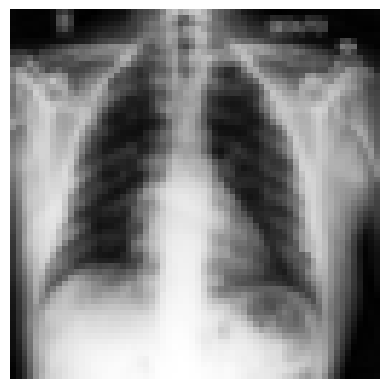

In [5]:
# -------------------- 1.3.3 读取数据：训练集 --------------------
data_path = 'covid19'

# ImageFolder将一个文件夹下的图片读取成数据集。
train_dataset = datasets.ImageFolder(
    root=f'{data_path}/train',
    transform=transform
)
print(f"训练集样本总数: {len(train_dataset)}")
img, label = train_dataset[0]   # 取出第一张图片
print(img.size())               # 输出尺寸
print(label)
print(img)
show_img(img)


# 定义DataLoader用于加载训练数据。
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True  # 训练时需要打乱数据
)

训练集样本总数: 251
ImageFolder 内部类顺序 (dataset.classes): ['Covid', 'Normal', 'Viral Pneumonia']
最终用于统计的类别顺序: ['Covid', 'Normal', 'Viral Pneumonia']

训练集类别统计：
0 - Covid: 111
1 - Normal: 70
2 - Viral Pneumonia: 70


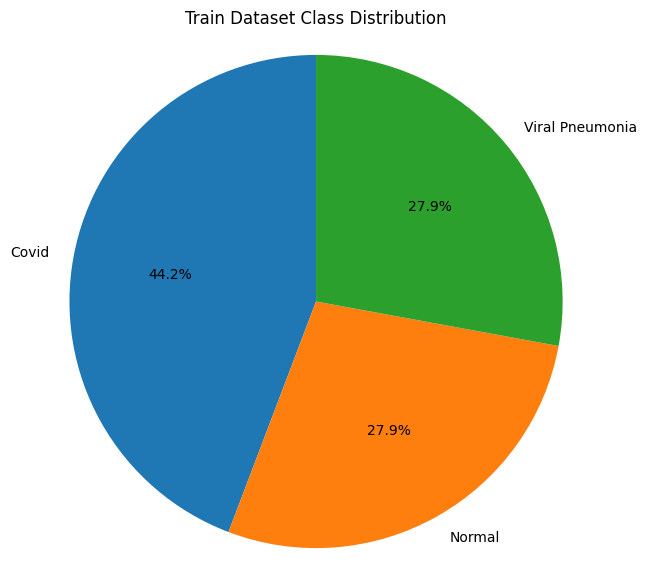

In [20]:
import os
from collections import Counter
from torchvision import datasets
import matplotlib.pyplot as plt

# ========== 配置 ==========
data_path = 'covid19'        # 数据根目录
transform = transform        # 假设你已经定义好 transform
CLASS_NAMES = ['Covid', 'Normal', 'Viral Pneumonia']
# 如果你要强制使用 ImageFolder 自带的类名把下面改成 True
use_dataset_classes = False
# =========================

# 读取训练集
train_dataset = datasets.ImageFolder(
    root=os.path.join(data_path, 'train'),
    transform=transform
)

print(f"训练集样本总数: {len(train_dataset)}")
print("ImageFolder 内部类顺序 (dataset.classes):", train_dataset.classes)

# 选择最终用于展示/打印的类别顺序
if use_dataset_classes:
    class_labels = train_dataset.classes
else:
    # 若 dataset.classes 和用户提供的 CLASS_NAMES 有交集且顺序合理，优先使用 dataset.classes
    if all(c in CLASS_NAMES for c in train_dataset.classes):
        class_labels = train_dataset.classes
    else:
        class_labels = CLASS_NAMES

print("最终用于统计的类别顺序:", class_labels)

# 统计 label（更快的方式：使用 train_dataset.targets）
try:
    label_counts = Counter(int(x) for x in train_dataset.targets)
except Exception:
    label_counts = Counter()
    for _, lbl in train_dataset:
        label_counts[int(lbl)] += 1

# 按 class_labels 顺序组织计数（若 label 索引超出范围会显示 0）
counts_ordered = [label_counts.get(i, 0) for i in range(len(class_labels))]

print("\n训练集类别统计：")
for idx, name in enumerate(class_labels):
    print(f"{idx} - {name}: {counts_ordered[idx]}")

# 绘制并显示饼图（扇形图）
plt.figure(figsize=(7, 7))
plt.pie(
    counts_ordered,
    labels=class_labels,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Train Dataset Class Distribution")
plt.axis('equal')  # 保证为圆形
plt.show()

# 可选：保存图片
# plt.savefig('train_class_distribution_pie.png', dpi=200, bbox_inches='tight')


In [6]:
# -------------------- 1.3.3 读取数据：测试集 (自行完成部分) --------------------
test_dataset = datasets.ImageFolder(
    root=f'{data_path}/noisy_test',
    transform=transform
)
print(f"测试集样本总数: {len(test_dataset)}")

# 定义DataLoader用于加载测试数据。
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False # 测试时不需要打乱数据
)

测试集样本总数: 66


In [7]:
# -------------------- 1.3.4 (1) 定义自编码器 (Autoencoder) --------------------
class Autoencoder(nn.Module):
    # 模型继承自nn.Module类，在__init__()函数中定义模型的结构。
    def __init__(self):
        super(Autoencoder, self).__init__()
        
        # 编码器 (Encoder): 提取特征并压缩数据 (使用 MaxPool 缩小尺寸)
        # 假设输入图片尺寸: 1x64x64
        self.encoder = nn.Sequential(
            # Conv1: 1x64x64 -> 32x64x64(卷积核 32, 步长 1, 填充 1)
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            # MaxPool1: 32x64x64 -> 32x32x32 (尺寸减半)
            nn.MaxPool2d(2, stride=2),
            # Conv2: 32x32x32 -> 64x32x32
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            # MaxPool2: 64x32x32 -> 64x16x16 (尺寸再次减半)
            nn.MaxPool2d(2, stride=2)
        )
        
        # 解码器 (Decoder): 从压缩特征重建图片并进行去噪 (使用 Upsampling 放大尺寸)
        # 输入尺寸: 64x16x16
        self.decoder = nn.Sequential(
            # Conv3: 64x16x16 -> 32x16x16
            nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            # Upsample1: 32x16x16 -> 32x32x32 (尺寸翻倍)
            nn.UpsamplingNearest2d(scale_factor=2),
            # Conv4: 32x32x32 -> 16x32x32
            nn.Conv2d(32, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            # Upsample2: 16x32x32 -> 16x64x64 (尺寸翻倍)
            nn.UpsamplingNearest2d(scale_factor=2),
            # Conv5: 16x64x64 -> 1x64x64 (输出通道为1，使用Sigmoid确保像素值在0-1之间)
            nn.Conv2d(16, 1, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid() 
        )

    # forward()函数中定义模型的前向传播过程。
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [8]:
# -------------------- 1.3.4 (2) 定义卷积神经网络 (CNN) --------------------
class CNN(nn.Module):
    # __init__()函数中定义模型的结构
    def __init__(self, in_channels=1):
        super(CNN, self).__init__()
        
        # 卷积层 1: 1x64x64 -> 16x64x64
        self.conv1 = nn.Conv2d(in_channels, out_channels=16, kernel_size=3, stride=1, padding=1)
        # 卷积层 2: 16x32x32 -> 32x32x32
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        
        # 最大池化层: 尺寸减半 (64->32, 32->16)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        
        # 全连接层 1: 输入尺寸为 32 * 16 * 16 (即 8192)
        # 注意: 这里根据卷积层的输出修正了尺寸，与图片中 32*64*64 的可能错误值不同。
        self.fc1 = nn.Linear(in_features=32 * 16 * 16, out_features=128)
        # 全连接层 2: 128 -> 32
        self.fc2 = nn.Linear(in_features=128, out_features=32)
        # 全连接层 3: 32 -> 3 (最终分类输出)
        self.fc3 = nn.Linear(in_features=32, out_features=3)

    # forward()函数中定义模型的前向传播过程
    def forward(self, x):
        # 卷积层 1 + ReLU + 池化
        x = self.pool(F.relu(self.conv1(x)))
        # 卷积层 2 + ReLU + 池化
        x = self.pool(F.relu(self.conv2(x)))
        
        # 展平操作: 将 32x16x16 展平为 8192
        # x.view(-1, D) 是 nn.Flatten() 的手动实现，其中 D = 32 * 16 * 16
        x = x.view(-1, 32 * 16 * 16) 
        
        # 全连接层 1 + ReLU
        x = F.relu(self.fc1(x))
        # 全连接层 2 + ReLU
        x = F.relu(self.fc2(x))
        # 全连接层 3 (输出层，无需激活函数，因为后续将使用 nn.CrossEntropyLoss)
        x = self.fc3(x)
        
        return x

In [9]:
# -------------------- 1.3.5 (1) 初始化模型与配置 --------------------

# (1) 初始化模型：实例化两个模型
autoencoder = Autoencoder().to(device) 
cnn_model = CNN().to(device)

# (2) 指定AE损失函数与优化器算法
# AE 选用均方误差 (MSELoss) 作为损失函数，用于衡量重建图片与干净图片的差异。
criterion_ae = nn.MSELoss()
# Adam作为优化器，用于更新自编码器的权重。
optimizer_ae = torch.optim.Adam(autoencoder.parameters(), lr=LR)

# AE 模型的保存路径
AE_MODEL_PATH = './autoencoder_model.pth'

# 确保 AE 模型处于训练模式 (如果需要再次训练的话)
autoencoder.train()

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): UpsamplingNearest2d(scale_factor=2.0, mode='nearest')
    (3): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): UpsamplingNearest2d(scale_factor=2.0, mode='nearest')
    (6): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): Sigmoid()
  )
)

In [10]:
# -------------------- 1.3.5 (1) 自编码器训练函数 --------------------

# 定义添加高斯噪声的函数 (假设噪声强度为 0.2)
def add_gaussian_noise(images):
    noise = torch.randn_like(images) * 0.2  
    noisy_images = images + noise
    noisy_images = torch.clamp(noisy_images, 0., 1.)
    return noisy_images

print("\n--- 开始训练自编码器 ---")
ae_losses = []

def train_autoencoder(epoch):
    autoencoder.train()
    running_loss = 0.0
    
    # tqdm 用于进度条可视化
    for batch_idx, (data, _) in enumerate(tqdm(train_loader, desc=f"AE Epoch {epoch}")):
        # ①从加载器中获取输入数据
        data = data.to(device) # 干净图片作为标签
        noisy_data = add_gaussian_noise(data) # 加噪图片作为输入
        
        # ②清空梯度
        optimizer_ae.zero_grad()
        
        # ③计算模型输出 (预测的去噪图片)
        output = autoencoder(noisy_data)
        
        # ④根据模型输出和标签计算loss
        loss = criterion_ae(output, data)
        
        # ⑤反向传播
        loss.backward()
        
        # ⑥更新模型
        optimizer_ae.step()
        
        # 累加并获取 loss 值 (loss.item() 获取 Tensor 值) 
        running_loss += loss.item()
        
    # 计算并打印平均 loss
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch}: Average AE Loss: {avg_loss:.6f}")
    return avg_loss

# 执行 AE 主训练循环
for epoch in range(1, EPOCHS + 1):
    loss = train_autoencoder(epoch)
    ae_losses.append(loss)
    
# 模型的保存
torch.save(autoencoder.state_dict(), AE_MODEL_PATH)
print(f"自编码器模型保存完毕: {AE_MODEL_PATH}")


--- 开始训练自编码器 ---


AE Epoch 1: 100%|██████████| 8/8 [00:07<00:00,  1.14it/s]


Epoch 1: Average AE Loss: 0.070740


AE Epoch 2: 100%|██████████| 8/8 [00:06<00:00,  1.16it/s]


Epoch 2: Average AE Loss: 0.037013


...

Epoch 28: Average AE Loss: 0.005159


AE Epoch 29: 100%|██████████| 8/8 [00:06<00:00,  1.18it/s]


Epoch 29: Average AE Loss: 0.005071


AE Epoch 30: 100%|██████████| 8/8 [00:06<00:00,  1.15it/s]

Epoch 30: Average AE Loss: 0.005006
自编码器模型保存完毕: ./autoencoder_model.pth


In [11]:
# -------------------- 1.3.5 (2) CNN 模型配置 --------------------

# 指定CNN损失函数与优化器算法
criterion_cnn = nn.CrossEntropyLoss()
# 为 CNN 定义优化器
optimizer_cnn = torch.optim.Adam(cnn_model.parameters(), lr=LR)

# CNN 模型的保存路径
CNN_MODEL_PATH = './cnn_model.pth'

# 导入已训练的自编码器权重，确保其能够用于去噪
autoencoder.load_state_dict(torch.load(AE_MODEL_PATH))

<All keys matched successfully>

In [12]:
# -------------------- 1.3.5 (2) CNN 训练函数 --------------------

# 用于存储训练过程中的 loss 和正确率，以便后续绘制结果
train_losses = []
train_accuracies = []

print("\n--- 开始训练 CNN 分类器 ---")

def train_cnn(epoch):
    cnn_model.train()
    autoencoder.eval() # 确保自编码器处于评估模式，不进行更新
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    for batch_idx, (data, target) in enumerate(tqdm(train_loader, desc=f"CNN Epoch {epoch}")):
        data, target = data.to(device), target.to(device)
        
        # 1. 数据预处理: 手动加噪
        noisy_data = add_gaussian_noise(data)
        
        # 2. 数据预处理: 通过自编码器去噪
        # torch.no_grad() 确保这一步不产生梯度，不更新自编码器权重 
        with torch.no_grad():
            denoised_data = autoencoder(noisy_data)
        
        # 清空梯度
        optimizer_cnn.zero_grad()
        
        # 计算模型输出
        output = cnn_model(denoised_data)
        
        # 计算 Loss
        loss = criterion_cnn(output, target)
        
        # 反向传播与更新
        loss.backward()
        optimizer_cnn.step()
        
        # 记录 loss
        running_loss += loss.item()
        
        # 计算正确率
        _, predicted = torch.max(output.data, 1)
        total_samples += target.size(0)
        # 计算当前批次中被正确判断的样本数 
        correct_predictions += (predicted == target).sum().item() 
        
    avg_loss = running_loss / len(train_loader)
    accuracy = 100 * correct_predictions / total_samples
    
    train_losses.append(avg_loss)
    train_accuracies.append(accuracy)
    
    print(f"CNN Train - Epoch {epoch}: Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")



--- 开始训练 CNN 分类器 ---


In [13]:
# -------------------- CNN 主训练循环 (需补充) --------------------
# 假设您已定义了 EPOCHS 和 CNN_MODEL_PATH = './cnn_model.pth'

print("\n--- 执行 CNN 主训练循环 ---")

# 执行 CNN 训练的主循环
for epoch in range(1, EPOCHS + 1):
    train_cnn(epoch)
    # (可选) 在每个 epoch 结束77后执行测试/验证

# -------------------- 模型保存 (需补充) --------------------
# 在所有 epoch 训练完成后，保存最终模型
torch.save(cnn_model.state_dict(), CNN_MODEL_PATH)
print(f"CNN 模型保存完毕: {CNN_MODEL_PATH}")


--- 执行 CNN 主训练循环 ---


CNN Epoch 1: 100%|██████████| 8/8 [00:10<00:00,  1.31s/it]


CNN Train - Epoch 1: Loss: 1.0619, Accuracy: 45.02%


CNN Epoch 2: 100%|██████████| 8/8 [00:09<00:00,  1.25s/it]


CNN Train - Epoch 2: Loss: 0.9379, Accuracy: 51.79%


...

CNN Train - Epoch 28: Loss: 0.0598, Accuracy: 98.80%


CNN Epoch 29: 100%|██████████| 8/8 [00:10<00:00,  1.27s/it]


CNN Train - Epoch 29: Loss: 0.0607, Accuracy: 96.81%


CNN Epoch 30: 100%|██████████| 8/8 [00:08<00:00,  1.02s/it]

CNN Train - Epoch 30: Loss: 0.0648, Accuracy: 97.21%
CNN 模型保存完毕: ./cnn_model.pth


In [14]:
# -------------------- 1.3.6 模型测试函数 --------------------

# 用于存储测试过程中的 loss 和正确率，以便后续绘制结果
test_losses = []
test_accuracies = []

def test_cnn(epoch):
    # 将模型设置为评估模式，关闭 Dropout 和 BatchNorm 等层
    cnn_model.eval()
    autoencoder.eval() # 自编码器也需设置为评估模式
    
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    # torch.no_grad() 关闭梯度计算，节省内存并加速运算
    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(tqdm(test_loader, desc=f"CNN Test Epoch {epoch}")):
            data, target = data.to(device), target.to(device)
            
            # 1. 数据预处理: 通过自编码器去噪
            # 指导书说明：测试集已经是加噪的图片，因此不必手动添加噪声。
            # 直接将加噪的测试数据输入自编码器进行去噪
            denoised_data = autoencoder(data)
            
            # 计算模型输出
            output = cnn_model(denoised_data)
            
            # 计算 Loss
            # 使用 CNN 训练时指定的交叉熵损失函数
            loss = criterion_cnn(output, target)
            
            # 记录 loss
            running_loss += loss.item()
            
            # 计算正确率
            _, predicted = torch.max(output.data, 1)
            total_samples += target.size(0)
            correct_predictions += (predicted == target).sum().item()
            
    avg_loss = running_loss / len(test_loader)
    accuracy = 100 * correct_predictions / total_samples
    
    test_losses.append(avg_loss)
    test_accuracies.append(accuracy)
    
    print(f"CNN Test - Epoch {epoch}: Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")
    
    return avg_loss, accuracy

In [15]:
# -------------------- CNN 训练与测试的主循环 --------------------

# 假设 train_cnn 函数和 test_cnn 函数已经定义
# 假设 autoencoder 和 cnn_model 已经初始化并加载了 AE 权重

print("\n--- 执行 CNN 训练与测试的主循环 ---")
train_losses = []
train_accuracies = []

test_losses = []
test_accuracies = []
# 执行训练和测试
for epoch in range(1, EPOCHS + 1):
    
    # 训练当前 epoch
    train_cnn(epoch)
    
    # 测试当前 epoch 训练后的模型性能
    test_cnn(epoch)

# 模型的保存
torch.save(autoencoder.state_dict(), AE_MODEL_PATH)
print(f"自编码器模型保存完毕: {AE_MODEL_PATH}")
torch.save(cnn_model.state_dict(), CNN_MODEL_PATH)
print(f"\nCNN 模型最终保存完毕: {CNN_MODEL_PATH}")


--- 执行 CNN 训练与测试的主循环 ---


CNN Epoch 1: 100%|██████████| 8/8 [00:07<00:00,  1.08it/s]


CNN Train - Epoch 1: Loss: 0.0987, Accuracy: 96.41%


CNN Test Epoch 1: 100%|██████████| 1/1 [00:01<00:00,  1.94s/it]


CNN Test - Epoch 1: Loss: 0.8640, Accuracy: 71.21%


...

CNN Test - Epoch 29: Loss: 0.8818, Accuracy: 81.82%


CNN Epoch 30: 100%|██████████| 8/8 [00:09<00:00,  1.18s/it]


CNN Train - Epoch 30: Loss: 0.0103, Accuracy: 100.00%


CNN Test Epoch 30: 100%|██████████| 1/1 [00:02<00:00,  2.28s/it]

CNN Test - Epoch 30: Loss: 1.3751, Accuracy: 72.73%
自编码器模型保存完毕: ./autoencoder_model.pth

CNN 模型最终保存完毕: ./cnn_model.pth


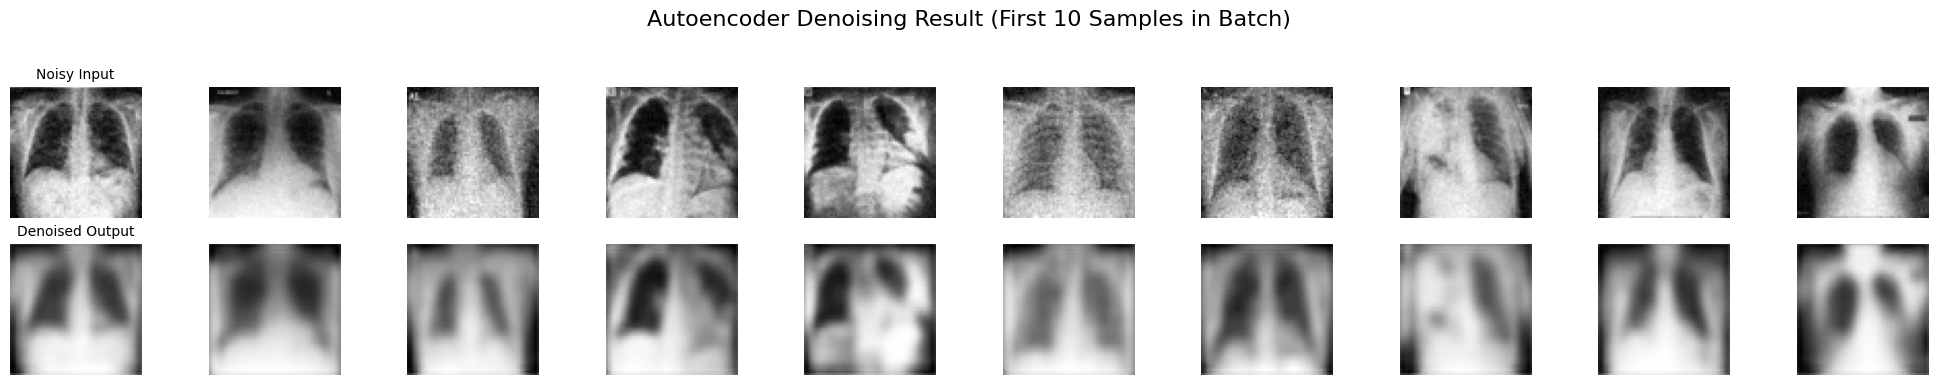

In [16]:
# -------------------- 1.3.7 (1) 自编码器结果绘制：批次对比 --------------------

# 展示批次中的前 N 个样本
N_DISPLAY = 10 

# 设置模型为评估模式，确保不计算梯度
autoencoder.eval() 
test_dataloader = test_loader 
tp = transforms.ToPILImage() 

# 1. 获取第一个批次的数据
try:
    data, _ = next(iter(test_dataloader))
except StopIteration:
    # 如果 test_loader 迭代完毕，重新初始化
    test_loader_iter = iter(test_loader)
    data, _ = next(test_loader_iter)

data = data.to(device)

# 2. 计算模型输出（去噪后的图片）
with torch.no_grad():
    output = autoencoder(data)

# 3. 创建图表：2 行 (输入/输出) x N 列 (N 个样本)
plt.figure(figsize=(20, 4))
plt.suptitle(f"Autoencoder Denoising Result (First {N_DISPLAY} Samples in Batch)", fontsize=16)

# 4. 循环绘制前 N 个样本的输入和输出
for i in range(N_DISPLAY):
    
    # --- 绘制加噪输入图片（第一行）---
    ax_noisy = plt.subplot(2, N_DISPLAY, i + 1)
    
    # 转换为 PIL Image 并显示
    noisy_img = tp(data[i].cpu()) 
    plt.imshow(noisy_img, cmap='gray')
    
    # 设置标题和坐标轴
    if i == 0:
        ax_noisy.set_title("Noisy Input", fontsize=10)
    plt.axis('off')
    
    # --- 绘制去噪后的输出图片（第二行）---
    ax_reconstructed = plt.subplot(2, N_DISPLAY, i + N_DISPLAY + 1)
    
    # 转换为 PIL Image 并显示
    reconstructed = tp(output[i].cpu())
    plt.imshow(reconstructed, cmap='gray')
    
    # 设置标题和坐标轴
    if i == 0:
        ax_reconstructed.set_title("Denoised Output", fontsize=10)
    plt.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 调整布局以适应suptitle
plt.show()

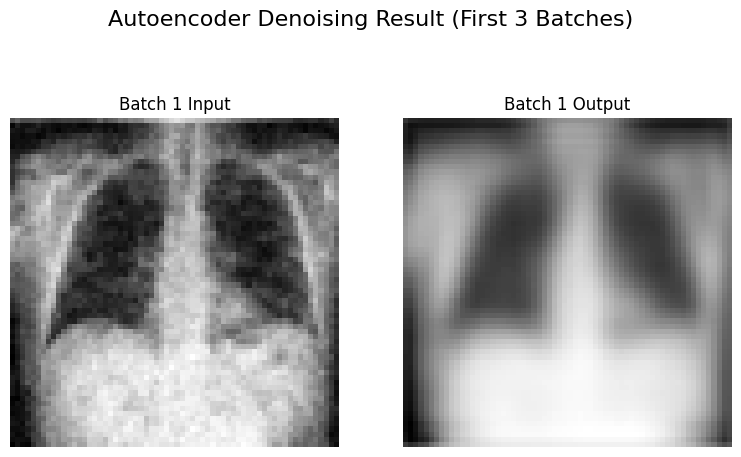

In [17]:
# -------------------- 1.3.7 (1) 自编码器结果绘制 (多批次单画板) --------------------

# 设置需要展示的批次数
N_DISPLAY_BATCHES = 3 

# 设置模型为评估模式
autoencoder.eval() 
test_dataloader = test_loader 
tp = transforms.ToPILImage() 

# 1. 在循环外部创建**唯一的**大画板 (3 行 2 列)
plt.figure(figsize=(8, 4 * N_DISPLAY_BATCHES))
plt.suptitle(f"Autoencoder Denoising Result (First {N_DISPLAY_BATCHES} Batches)", fontsize=16) 

# 2. 遍历 test_dataloader
with torch.no_grad():
    for i, (data, _) in enumerate(test_dataloader):
        
        # 达到预定批次数量，立即跳出循环
        if i >= N_DISPLAY_BATCHES:
            break 

        # 准备数据
        data = data.to(device)
        output = autoencoder(data)
        
        # 提取当前批次的第一个样本
        noisy_img = tp(data[0].cpu()) 
        reconstructed = tp(output[0].cpu()) 
        
        # 3. 绘制加噪输入 (第 i+1 行，第 1 列)
        plot_idx_input = (i * 2) + 1 # 对应子图序号 1, 3, 5
        ax_input = plt.subplot(N_DISPLAY_BATCHES, 2, plot_idx_input)
        plt.imshow(noisy_img, cmap='gray')
        ax_input.set_title(f"Batch {i+1} Input")
        plt.axis('off')

        # 4. 绘制去噪后的输出 (第 i+1 行，第 2 列)
        plot_idx_output = (i * 2) + 2 # 对应子图序号 2, 4, 6
        ax_output = plt.subplot(N_DISPLAY_BATCHES, 2, plot_idx_output)
        plt.imshow(reconstructed, cmap='gray')
        ax_output.set_title(f"Batch {i+1} Output")
        plt.axis('off')

# 5. 在循环结束后，调用 plt.show() 一次性显示所有子图
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()


--- 绘制 CNN 训练和测试结果 ---


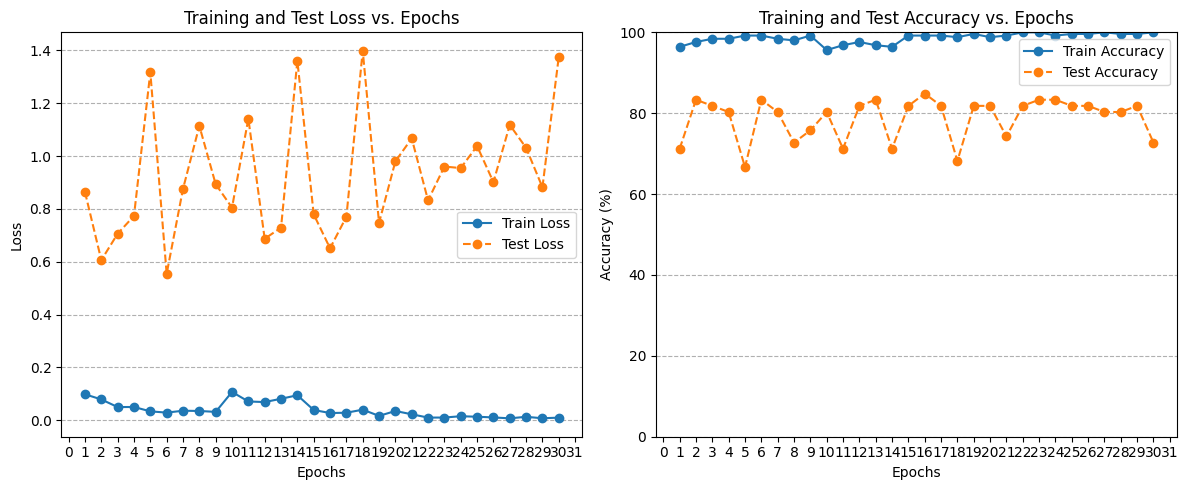

In [18]:
# -------------------- 1.3.7 (2) CNN 训练过程正确率及 Loss 可视化 --------------------

import matplotlib.pyplot as plt
from matplotlib.pyplot import MultipleLocator

print("\n--- 绘制 CNN 训练和测试结果 ---")

# 假设 EPOCHS 变量已定义，且损失列表已填充
epochs_range = list(range(1, EPOCHS + 1)) 

# 创建一个包含两个子图的画板
plt.figure(figsize=(12, 5))

# --- 1. 绘制 Loss 曲线图 (左侧) ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss', marker='o', linestyle='-')
plt.plot(epochs_range, test_losses, label='Test Loss', marker='o', linestyle='--')
plt.title('Training and Test Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(axis='y', linestyle='--') # 背景绘制虚线
# 设置 x 轴刻度，确保每个 epoch 都有刻度 (与指导书示例图一致)
ax_loss = plt.gca()
ax_loss.xaxis.set_major_locator(MultipleLocator(1))


# --- 2. 绘制 Accuracy 曲线图 (右侧) ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Train Accuracy', marker='o', linestyle='-')
plt.plot(epochs_range, test_accuracies, label='Test Accuracy', marker='o', linestyle='--')
plt.title('Training and Test Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
# 设置 y 轴范围 (参考指导书示例图，通常设置为 0 到 100)
plt.ylim(0, 100) 
plt.grid(axis='y', linestyle='--')
# 设置 x 轴刻度为 1 的倍数
ax_acc = plt.gca()
ax_acc.xaxis.set_major_locator(MultipleLocator(1))

plt.tight_layout() # 自动调整子图参数，使之填充整个图像区域
plt.show()